**Image recognition from MNIST using CNN**



#Importing Libraries


In [ ]:
from tensorflow.keras.datasets import mnist #Load the mnist database
from tensorflow.keras.models import Sequential #Feedforward network

# Base layers for stacked networks
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator # working with images
from tensorflow.keras.optimizers import Adam, Adadelta # optimizers
from tensorflow.keras import utils #Use for to_categoricall
from tensorflow.keras.preprocessing import image #For rendering images
from google.colab import files #To upload your image

import numpy as np #Library for working with arrays
import matplotlib.pyplot as plt #For drawing plots
from PIL import Image #For rendering images
import random #To generate random numbers

import math # For rounding
import os #For working with files

# connect the disk.
from google.colab import drive

%matplotlib inline

# Image recognition from the MNIST data

MNIST is a large database of handwritten digits


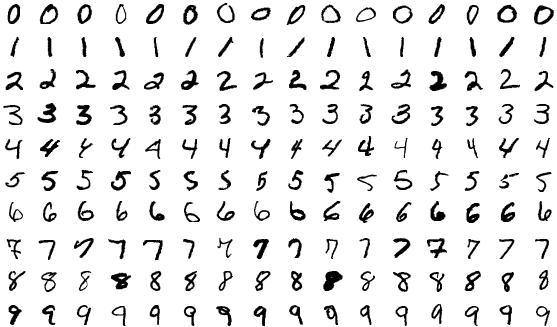

In [ ]:
#Loading MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print (x_train.shape) # dimension of training input images
print (y_train.shape) # dimension of training output
print (y_train[0:9]) # displaying first 10 training outputs

(60000, 28, 28)
(60000,)
[5 0 4 1 9 2 1 3 1]


0
1
2
3
4
5
6
7
8
9


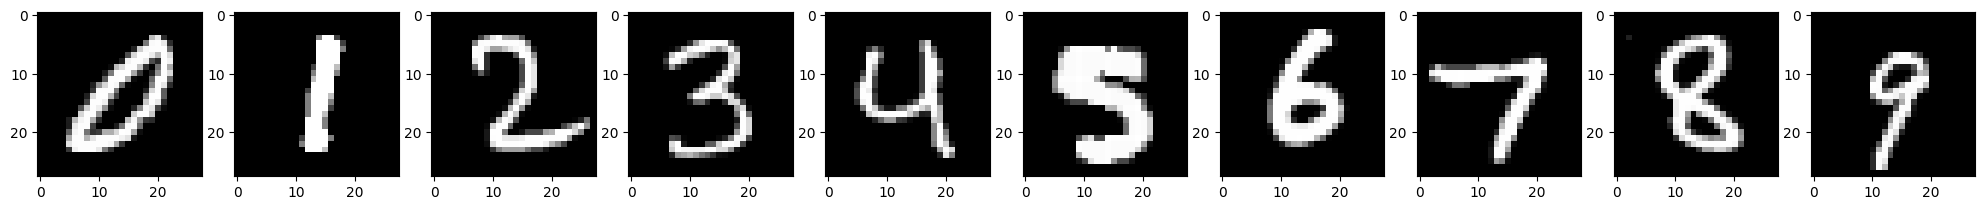

In [ ]:
# Display 1 randomly selected image from each class

fig, axs = plt.subplots(1, 10, figsize=(25, 3))  # create subplots
for i in range(10): #going through each classes
  label_indexes = np.where(y_train==i)[0] # Getting all the indices of class i from the y_train data
  index = random.choice(label_indexes) # Randomly select an index from the list
  img = x_train[index]
  axs[i].imshow(Image.fromarray(img), cmap='gray') # Display the image of the selected index
  print(y_train[index]) # display corresponding output class

plt.show() # Show Images

In [ ]:
# y_train and y_test categorical data into one hot encoding format
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

#Adding dimension 1 at the end, since data is black and white
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

In [ ]:
#viewing first 10 rows of y_train after changing into one hot encoding
y_train [0:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [ ]:
# Checking all training and testing data formats
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)
(60000, 10)
(10000, 10)


In [ ]:
# batch size
batch_size = 128

# Creating sequantial model
model = Sequential()

# Convolutional layer
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))

# To add a non-default stride (optional)
# model.add(Conv2D(32, (3, 3), padding='same', strides=(2, 2), activation='relu', input_shape=(28, 28, 1)))

# Convolutional layer
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))

# Subsampling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Dropout regularization layer
model.add(Dropout(0.25))

model.add(Flatten())

# Fully connected layer
model.add(Dense(256, activation='relu'))

# Dropout layer
model.add(Dropout(0.25))

# Output layer: Fully connected layer
model.add(Dense(10, activation='softmax'))

# Compilation
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,605,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,618,026 (6.17 MB)

 Trainable params: 1,618,026 (6.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 151s 318ms/step - accuracy: 0.8380 - loss: 3.0898 - val_accuracy: 0.9802 - val_loss: 0.0640
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 310ms/step - accuracy: 0.9739 - loss: 0.0857 - val_accuracy: 0.9846 - val_loss: 0.0465
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 304ms/step - accuracy: 0.9807 - loss: 0.0610 - val_accuracy: 0.9864 - val_loss: 0.0418
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 210s 321ms/step - accuracy: 0.9847 - loss: 0.0452 - val_accuracy: 0.9855 - val_loss: 0.0450
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 311ms/step - accuracy: 0.9869 - loss: 0.0413 - val_accuracy: 0.9854 - val_loss: 0.0489
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 311ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9868 - val_loss: 0.0441
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 307ms/step - accuracy: 0.9890 - loss: 0.0328 - val_accuracy: 0.9852 - val_loss: 0.0472
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 308ms/step - accuracy: 0.9910 -

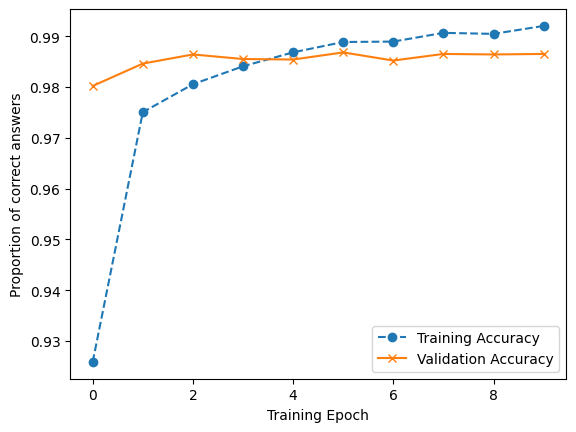

In [ ]:
# Training the model
history = model.fit(x_train, y_train,
                    epochs=10,  # Increase the number of epochs
                    batch_size=batch_size,
                    validation_data=(x_test, y_test))

# DIsplaying training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', linestyle='--')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x', linestyle='-')
plt.xlabel('Training Epoch')
plt.ylabel('Proportion of correct answers')
plt.legend()
plt.show()


#**Number recognition based on test data**



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Network Output [1.0000000e+00 7.5106469e-18 1.8954365e-13 2.5822438e-21 5.2158016e-20
 9.6211064e-20 4.2633108e-16 7.4111841e-16 1.6240281e-14 4.4607882e-18]
Recognized digit:  0
Actual digit:  0


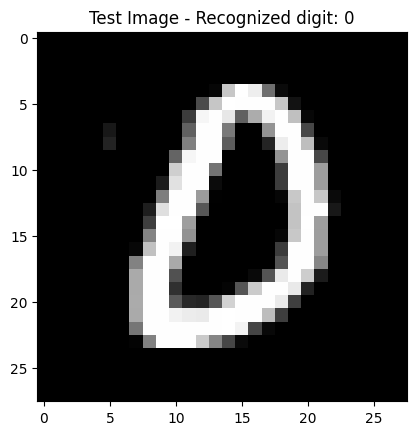

In [ ]:
# Random number selection from the test data
n = np.random.randint(x_test.shape[0])

# Prediction
prediction = model.predict(x_test)

# Printing the results
print("Network Output", prediction[n])
print("Recognized digit: ", np.argmax(prediction[n]))
print("Actual digit: ", np.argmax(y_test[n]))

# Display the test image
plt.imshow(x_test[n].reshape(28, 28), cmap='gray')
plt.title(f"Test Image - Recognized digit: {np.argmax(prediction[n])}")
plt.show()